# 梯度下降完整实战笔记（房价预测 + 优化器 + 学习率）📊

## 一、模拟数据生成

我们生成 100 套房屋数据，真实规律为：

**房价 = 2.5 × 面积 (平米) + 30**（等价于 **250 × 面积 (百平米) + 30**）

为稳定梯度下降，将面积单位从平米转换为百平米（范围 0.9-1.5）。

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 固定随机种子，保证结果可复现
np.random.seed(42)
n_samples = 100

# 生成随机面积（90-150平米），转换为百平米
areas_m2 = np.random.uniform(90, 150, n_samples)
areas = areas_m2 / 100

# 生成房价数据（加入随机噪声模拟真实场景）
prices = 250 * areas + 30 + np.random.randn(n_samples) * 15

# 打印数据基本信息
print(f"房屋数量: {len(areas)} 套")
print(f"面积范围: {areas_m2.min():.1f} - {areas_m2.max():.1f} 平米 ({areas.min():.2f} - {areas.max():.2f} 百平米)")
print(f"价格范围: {prices.min():.1f} - {prices.max():.1f} 万")
print(f"真实规律: 房价 = 2.5 × 面积(平米) + 30")

房屋数量: 100 套
面积范围: 90.3 - 149.2 平米 (0.90 - 1.49 百平米)
价格范围: 248.0 - 414.8 万
真实规律: 房价 = 2.5 × 面积(平米) + 30


## 二、基础梯度下降算法实现

基于均方误差（MSE）损失函数，实现梯度下降来拟合线性回归参数 w 和 b。

In [7]:
def gradient_descent(X, y, lr=0.1, epochs=200):
    # 初始化参数 w（权重）和 b（偏置）
    w, b = 0.0, 0.0
    n = len(X)  # 样本数量
    
    # 初始化历史记录：保存每一轮的 w、b 和损失值
    history = {'w': [w], 'b': [b], 'loss': [np.mean((w*X + b - y)**2)]}
    
    # 迭代训练
    for epoch in range(epochs):
        # 1. 计算当前模型预测值
        y_pred = w * X + b
        
        # 2. 计算损失函数对 w 和 b 的梯度
        dw = (2/n) * np.sum((y_pred - y) * X)  # 对 w 的偏导
        db = (2/n) * np.sum(y_pred - y)        # 对 b 的偏导
        
        # 3. 沿梯度反方向更新参数
        w -= lr * dw
        b -= lr * db
        
        # 4. 记录当前轮的参数和损失
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(np.mean((y_pred - y)**2))
        
        # 5. 每隔 1% 训练轮数，打印训练进度
        if epoch % (epochs/100) == 0:
            print(f"迭代 {epoch:3d}: w={w:.2f}, b={b:.2f}, loss={history['loss'][-1]:.2f}")
    
    return history

## 三、基础模型训练与结果查看

调用梯度下降函数进行训练，并输出最终拟合结果。

In [8]:
# 执行梯度下降训练
history = gradient_descent(areas, prices, lr=0.01, epochs=100000)

# 输出最终拟合结果（将 w 转换回平米单位）
print(f"\n最终结果: 房价 = {history['w'][-1]/100:.3f} × 面积(平米) + {history['b'][-1]:.2f}")

迭代   0: w=7.85, b=6.51, loss=107933.06
迭代 1000: w=179.58, b=114.15, loss=291.90
迭代 2000: w=193.12, b=97.93, loss=246.98
迭代 3000: w=203.55, b=85.43, loss=220.33
迭代 4000: w=211.59, b=75.81, loss=204.53
迭代 5000: w=217.77, b=68.40, loss=195.15
迭代 6000: w=222.54, b=62.70, loss=189.59
迭代 7000: w=226.21, b=58.30, loss=186.29
迭代 8000: w=229.04, b=54.91, loss=184.33
迭代 9000: w=231.21, b=52.31, loss=183.17
迭代 10000: w=232.89, b=50.30, loss=182.49
迭代 11000: w=234.18, b=48.75, loss=182.08
迭代 12000: w=235.17, b=47.56, loss=181.83
迭代 13000: w=235.94, b=46.65, loss=181.69
迭代 14000: w=236.53, b=45.94, loss=181.61
迭代 15000: w=236.98, b=45.39, loss=181.56
迭代 16000: w=237.33, b=44.98, loss=181.53
迭代 17000: w=237.60, b=44.65, loss=181.51
迭代 18000: w=237.81, b=44.40, loss=181.50
迭代 19000: w=237.97, b=44.21, loss=181.49
迭代 20000: w=238.09, b=44.07, loss=181.49
迭代 21000: w=238.19, b=43.95, loss=181.48
迭代 22000: w=238.26, b=43.86, loss=181.48
迭代 23000: w=238.32, b=43.80, loss=181.48
迭代 24000: w=238.36, b=43.7

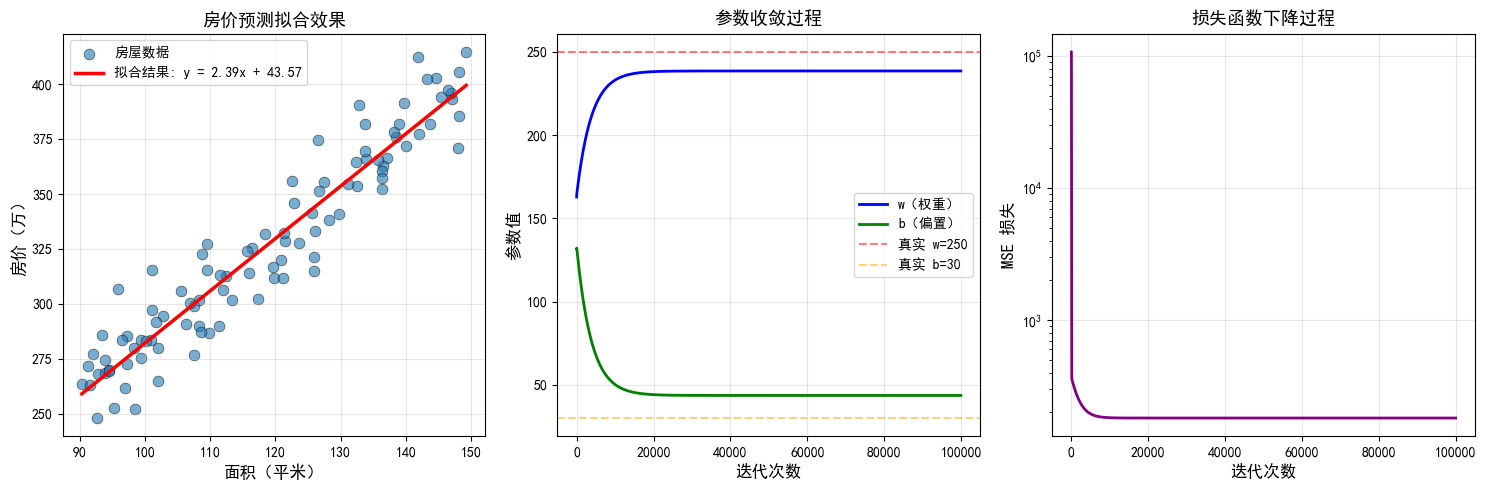

In [9]:
# ============== 可视化训练过程 ==============
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 左图：拟合效果
axes[0].scatter(areas_m2, prices, alpha=0.6, s=60, edgecolors='black', linewidth=0.5, label='房屋数据')
x_fit = np.linspace(areas_m2.min(), areas_m2.max(), 100)
y_fit = history['w'][-1]/100 * x_fit + history['b'][-1]
axes[0].plot(x_fit, y_fit, 'r-', linewidth=2.5, label=f'拟合结果: y = {history["w"][-1]/100:.2f}x + {history["b"][-1]:.2f}')
axes[0].set_xlabel('面积（平米）', fontsize=12)
axes[0].set_ylabel('房价（万）', fontsize=12)
axes[0].set_title('房价预测拟合效果', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 中图：参数收敛过程（跳过前100个迭代避免初始震荡）
axes[1].plot(history['w'][100:], 'b-', linewidth=2, label='w（权重）')
axes[1].plot(history['b'][100:], 'g-', linewidth=2, label='b（偏置）')
axes[1].axhline(y=250, color='r', linestyle='--', alpha=0.5, label='真实 w=250')
axes[1].axhline(y=30, color='orange', linestyle='--', alpha=0.5, label='真实 b=30')
axes[1].set_xlabel('迭代次数', fontsize=12)
axes[1].set_ylabel('参数值', fontsize=12)
axes[1].set_title('参数收敛过程', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 右图：损失函数下降过程
axes[2].plot(history['loss'], 'purple', linewidth=2)
axes[2].set_xlabel('迭代次数', fontsize=12)
axes[2].set_ylabel('MSE 损失', fontsize=12)
axes[2].set_title('损失函数下降过程', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')  # 使用对数坐标更清晰

plt.tight_layout()
plt.show()

## 四、核心原理回顾

### 1. 损失函数（MSE）

$$L(w,b) = \frac{1}{n}\sum_{i=1}^{n}(wx_i + b - y_i)^2$$

训练目标是最小化 $L(w,b)$。

### 2. 梯度计算

对 $w$ 求偏导：

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}(wx_i + b - y_i) \cdot x_i$$

对 $b$ 求偏导：

$$\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(wx_i + b - y_i)$$

### 3. 参数更新公式

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

$$b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

其中 $\eta$ 为学习率，控制参数更新的步长。

## 五、学习率对梯度下降的影响（f(x)=x² 可视化）

### 1. 学习率核心作用

学习率直接决定参数更新步长，是梯度下降的关键超参数：

- **太小**：收敛极慢，蜗牛爬坡
- **合适**：快速稳定收敛
- **偏大**：剧烈震荡，无法收敛
- **过大**：梯度爆炸，参数发散

### 2. 完整代码

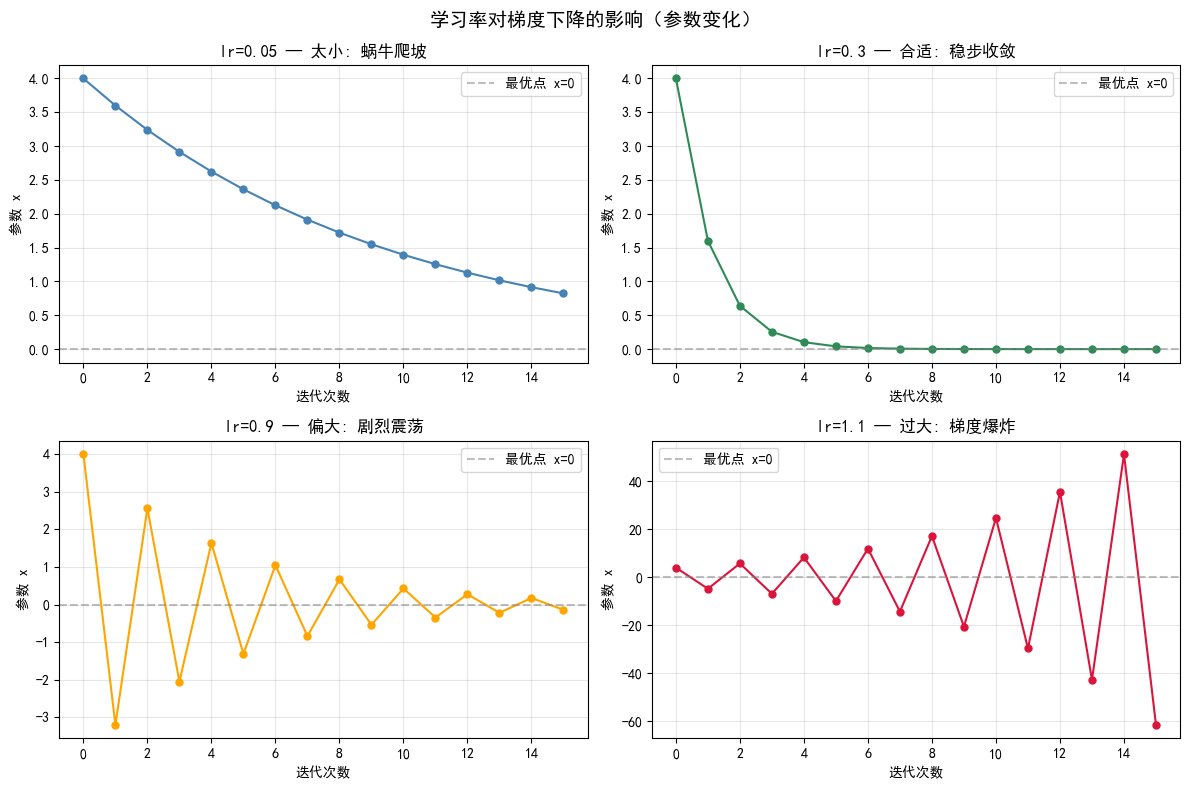

C:\Users\Cabbage\AppData\Local\Temp\ipykernel_28292\76213096.py:72: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()


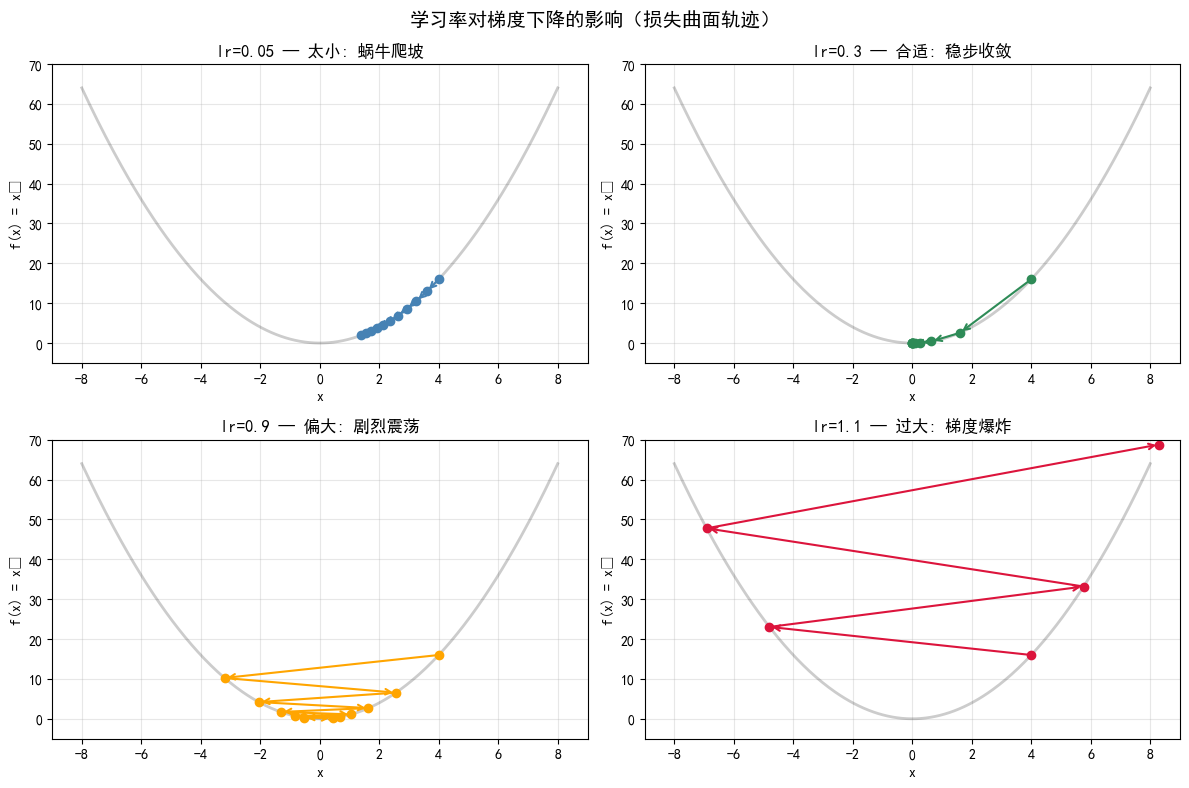

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ============== 核心逻辑 ==============
def gradient_descent(start_x, lr, n_steps=15):
    """在 f(x)=x² 上做梯度下降，返回每一步的 x 值"""
    trajectory = [start_x]
    x = start_x
    for _ in range(n_steps):
        grad = 2 * x          # f'(x) = 2x
        x = x - lr * grad     # 参数更新
        trajectory.append(x)
        if abs(x) > 500:      # 已经爆炸，提前停
            break
    return trajectory

# ============== 四种学习率对比 ==============
x0 = 4.0
configs = [
    (0.05, '太小: 蜗牛爬坡',    'steelblue'),
    (0.3,  '合适: 稳步收敛',    'seagreen'),
    (0.9,  '偏大: 剧烈震荡',    'orange'),
    (1.1,  '过大: 梯度爆炸',    'crimson'),
]

# ---------- 图1: 参数值随迭代变化 ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (lr, title, color) in zip(axes.flatten(), configs):
    traj = gradient_descent(x0, lr)
    ax.plot(range(len(traj)), traj, 'o-', color=color, markersize=5)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='最优点 x=0')
    ax.set_title(f'lr={lr} — {title}', fontsize=12)
    ax.set_xlabel('迭代次数')
    ax.set_ylabel('参数 x')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('学习率对梯度下降的影响（参数变化）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- 图2: 在损失曲线上可视化轨迹 ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x_curve = np.linspace(-8, 8, 300)

for ax, (lr, title, color) in zip(axes.flatten(), configs):
    traj = gradient_descent(x0, lr, n_steps=10)
    # 只保留不越界的点，方便画图
    traj_plot = [x for x in traj if abs(x) <= 10]

    ax.plot(x_curve, x_curve**2, 'k-', alpha=0.2, linewidth=2)  # 损失曲线 f(x)=x²
    ax.plot(traj_plot, [x**2 for x in traj_plot], 'o', color=color, markersize=6)

    # 画箭头连接每一步迭代轨迹
    for i in range(len(traj_plot) - 1):
        ax.annotate('', xy=(traj_plot[i+1], traj_plot[i+1]**2),
                    xytext=(traj_plot[i], traj_plot[i]**2),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    ax.set_title(f'lr={lr} — {title}', fontsize=12)
    ax.set_xlim(-9, 9)
    ax.set_ylim(-5, 70)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x) = x²')
    ax.grid(True, alpha=0.3)

plt.suptitle('学习率对梯度下降的影响（损失曲面轨迹）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 六、Adam 优化器实战（深度学习首选）

### 1. 核心原理

Adam = 动量法（Momentum）+ RMSProp，自适应学习率，收敛速度远超基础梯度下降。

### 2. 完整代码

In [11]:
def adam_optimizer(X, y, lr=0.1, epochs=200, beta1=0.9, beta2=0.999, epsilon=1e-8):
    # 初始化参数
    w, b = 0.0, 0.0
    n = len(X)
    
    # ============== Adam 特有的状态变量初始化 ==============
    m_w, v_w = 0.0, 0.0  # w 的一阶矩和二阶矩
    m_b, v_b = 0.0, 0.0  # b 的一阶矩和二阶矩
    # ======================================================
    
    # 初始化历史记录
    history = {'w': [w], 'b': [b], 'loss': [np.mean((w*X + b - y)**2)]}
    
    # 进行迭代训练
    for epoch in range(epochs):
        t = epoch + 1  # Adam 的时间步 t 从 1 开始，用于偏差校正
        
        # 1. 计算当前预测值
        y_pred = w * X + b
        
        # 2. 计算当前梯度（这部分和普通梯度下降完全一样）
        dw = (2/n) * np.sum((y_pred - y) * X)
        db = (2/n) * np.sum(y_pred - y)
        
        # ============== Adam 核心参数更新逻辑 ==============
        # 3. 更新一阶矩估计（动量：累积历史梯度方向）
        m_w = beta1 * m_w + (1 - beta1) * dw
        m_b = beta1 * m_b + (1 - beta1) * db
        
        # 4. 更新二阶矩估计（RMSProp：累积历史梯度平方）
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        
        # 5. 计算偏差校正后的一阶和二阶矩（解决初期向 0 偏移的问题）
        m_w_hat = m_w / (1 - beta1**t)
        m_b_hat = m_b / (1 - beta1**t)
        v_w_hat = v_w / (1 - beta2**t)
        v_b_hat = v_b / (1 - beta2**t)
        
        # 6. 使用 Adam 公式更新参数
        w -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
        b -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)
        # ======================================================
        
        # 计算当前 loss
        current_loss = np.mean((w*X + b - y)**2)
        
        # 记录参数和损失
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(current_loss)
        
        # 每隔 1% 训练轮数，打印一次进度（防止epochs较小报错，加个max限制）
        print_step = max(1, int(epochs / 100))
        if epoch % print_step == 0:
            print(f"迭代 {epoch:5d}: w={w:.4f}, b={b:.4f}, loss={current_loss:.4f}")
    
    return history

# ============== 运行测试 ==============
history = adam_optimizer(areas, prices, lr=0.1, epochs=50000)

print(f"\n最终结果: 房价 = {history['w'][-1]/100:.3f} × 面积(平米) + {history['b'][-1]:.2f}")

迭代     0: w=0.1000, b=0.1000, loss=107789.5449
迭代   500: w=46.1844, b=46.1517, loss=51867.0521
迭代  1000: w=83.7157, b=83.5560, loss=21384.4726
迭代  1500: w=112.3454, b=111.9089, loss=7211.7564
迭代  2000: w=131.9910, b=131.0488, loss=2016.5322
迭代  2500: w=143.5142, b=141.7486, loss=665.2655
迭代  3000: w=149.0809, b=146.1054, loss=443.7964
迭代  3500: w=151.4611, b=146.8415, loss=420.6028
迭代  4000: w=152.7851, b=146.0270, loss=414.5129
迭代  4500: w=154.0727, b=144.5837, loss=407.7859
迭代  5000: w=155.6504, b=142.7024, loss=399.4222
迭代  5500: w=157.6327, b=140.3310, loss=389.1192
迭代  6000: w=160.1102, b=137.3670, loss=376.5928
迭代  6500: w=163.1802, b=133.6940, loss=361.6110
迭代  7000: w=166.9439, b=129.1913, loss=344.0606
迭代  7500: w=171.4955, b=123.7460, loss=324.0379
迭代  8000: w=176.9051, b=117.2741, loss=301.9513
迭代  8500: w=183.1944, b=109.7499, loss=278.6088
迭代  9000: w=190.3055, b=101.2423, loss=255.2407
迭代  9500: w=198.0699, b=91.9530, loss=233.3922
迭代 10000: w=206.1854, b=82.2433, loss=21

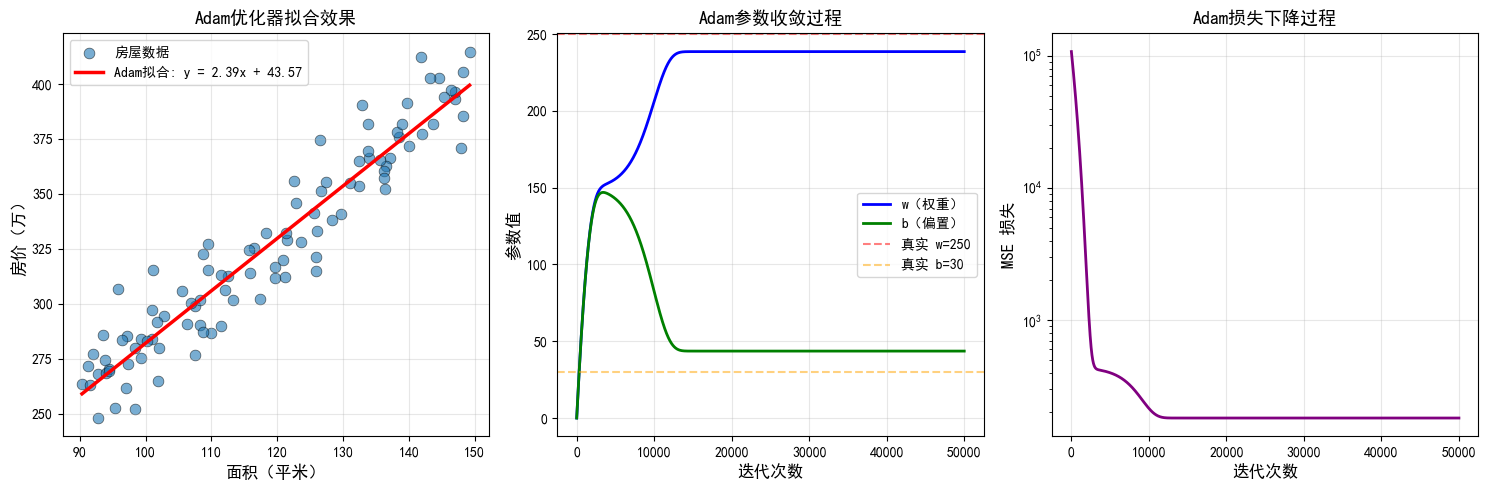

In [12]:
# ============== 可视化 Adam 优化器训练过程 ==============
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 左图：拟合效果
axes[0].scatter(areas_m2, prices, alpha=0.6, s=60, edgecolors='black', linewidth=0.5, label='房屋数据')
x_fit = np.linspace(areas_m2.min(), areas_m2.max(), 100)
y_fit = history['w'][-1]/100 * x_fit + history['b'][-1]
axes[0].plot(x_fit, y_fit, 'r-', linewidth=2.5, label=f'Adam拟合: y = {history["w"][-1]/100:.2f}x + {history["b"][-1]:.2f}')
axes[0].set_xlabel('面积（平米）', fontsize=12)
axes[0].set_ylabel('房价（万）', fontsize=12)
axes[0].set_title('Adam优化器拟合效果', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 中图：参数收敛过程
axes[1].plot(history['w'], 'b-', linewidth=2, label='w（权重）')
axes[1].plot(history['b'], 'g-', linewidth=2, label='b（偏置）')
axes[1].axhline(y=250, color='r', linestyle='--', alpha=0.5, label='真实 w=250')
axes[1].axhline(y=30, color='orange', linestyle='--', alpha=0.5, label='真实 b=30')
axes[1].set_xlabel('迭代次数', fontsize=12)
axes[1].set_ylabel('参数值', fontsize=12)
axes[1].set_title('Adam参数收敛过程', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 右图：损失函数下降过程
axes[2].plot(history['loss'], 'purple', linewidth=2)
axes[2].set_xlabel('迭代次数', fontsize=12)
axes[2].set_ylabel('MSE 损失', fontsize=12)
axes[2].set_title('Adam损失下降过程', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')  # 使用对数坐标

plt.tight_layout()
plt.show()

## 七、梯度下降的三种核心变体

| 算法名称 | 全称 | 数据使用量 | 核心特点 |
|---------|------|-----------|----------|
| **BGD** | 全量梯度下降 | 全部训练数据 | 梯度精准，速度极慢，不适合大数据 |
| **SGD** | 随机梯度下降 | 单条数据 | 速度快，噪声大，震荡剧烈 |
| **Mini-batch GD** | 小批量梯度下降 | 一小批数据 (32/64) | 业界标准，兼顾速度与稳定性 |